<a href="https://colab.research.google.com/github/AnnaShtyn/python_for_hw_tasks/blob/main/Anna_Shtyn_HW_16_2_%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D0%BA%D1%80%D0%B5%D0%B4%D0%B8%D1%82%D0%BD%D0%BE%D0%B3%D0%BE_%D1%80%D0%B8%D0%B7%D0%B8%D0%BA%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
pd.set_option('display.max_columns', None)

# 1.1,2)
df = pd.read_csv('drive/MyDrive/credit_risk_dataset.csv')
df.shape

(32581, 12)

In [ ]:
# 1.3)
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
# 1.4)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
# 1.5)
loan_status_perc = df['loan_status'].value_counts(normalize=True) * 100
loan_status_perc

# Це задача незбалансованої класифікації, оскільки розподіл даних ціл. змінної
#  78/22.

,proportion
loan_status,
0,78.183604
1,21.816396



---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [ ]:
# 2.1)
missing = df.isnull().sum()
missing_perc = (missing / len(df) * 100).round(2)

display(missing_perc)

,0
person_age,0.00
person_income,0.00
person_home_ownership,0.00
person_emp_length,2.75
loan_intent,0.00
loan_grade,0.00
loan_amnt,0.00
loan_int_rate,9.56
loan_status,0.00
loan_percent_income,0.00


In [ ]:
# Визначаємо медіану для вищезазначених стовпців
pers_emp_length_median = df.groupby('loan_status')['person_emp_length'].median()
loan_int_rate_median = df.groupby('loan_status')['loan_int_rate'].median()

print(pers_emp_length_median, loan_int_rate_median)

loan_status
0    4.0
1    3.0
Name: person_emp_length, dtype: float64 loan_status
0    10.59
1    13.49
Name: loan_int_rate, dtype: float64


In [ ]:
# В колонках з пропущеними значеннями заповнимо пропущені значення медіанами, та перевіримо чи є досі пропуски
df['person_emp_length'] = df['person_emp_length'].fillna(df['loan_status'].map(pers_emp_length_median))
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_status'].map(loan_int_rate_median))

missing = df.isnull().sum()
display(missing[missing > 0])

# Тепер NaN відсутні

,0


In [ ]:
# 2.2)
df.select_dtypes('number').describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.76,9589.37,11.03,0.22,0.17,5.80
std,6.35,61983.12,4.09,6322.09,3.10,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,8.49,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.74,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.43,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


In [ ]:
# 2.3) Застосуємо 'ящик з вусами' для наглядності викидів змінної 'person_income'
fig = px.box(df, y='person_income', labels={'person_income':'Річний дохід'}, title='Аналіз викидів змінної річного доходу')
fig.show()

# та розрахуємо за допомогою міжквартильного розмаху
quart_1 = df['person_income'].quantile(0.25)
quart_3 = df['person_income'].quantile(0.75)
interquart_range = quart_3 - quart_1

lower_outliers = quart_1 - 1.5 * interquart_range
higher_outliers = quart_3 + 1.5 * interquart_range
print(f'Нижня межа викидів: {lower_outliers}\nВерхня межа викидів: {higher_outliers}')

# Отже, річний дохід вище 140 250 - це викиди, усунемо їх і запишемо дані в новий df
df_clean = df[df['person_income'] < higher_outliers]
print(f"\nРозмір датафрейму без 'викидів' {df_clean.shape}")

# Як бачимо, 1.5тис. записів відсіялось

Нижня межа викидів: -22550.0
Верхня межа викидів: 140250.0

Розмір датафрейму без 'викидів' (31097, 12)


In [ ]:
# 2.4)
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
targ_vs_cat_var = pd.concat([pd.crosstab(df_clean[col], df_clean['loan_status'], normalize='index') for col in cat_cols], keys=cat_cols).round(2)

display(targ_vs_cat_var)

loan_status                                     0     1
person_home_ownership     MORTGAGE           0.87  0.13
                          OTHER              0.68  0.32
                          OWN                0.92  0.08
                          RENT               0.68  0.32
loan_intent               DEBTCONSOLIDATION  0.71  0.29
                          EDUCATION          0.82  0.18
                          HOMEIMPROVEMENT    0.73  0.27
                          MEDICAL            0.73  0.27
                          PERSONAL           0.79  0.21
                          VENTURE            0.85  0.15
loan_grade                A                  0.90  0.10
                          B                  0.83  0.17
                          C                  0.79  0.21
                          D                  0.40  0.60
                          E                  0.34  0.66
                          F                  0.28  0.72
                          G                  0.02  0.98
cb_person_default_on_file N                  0.81  0.19
                          Y                  0.61  0.39

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31097 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  31097 non-null  int64  
 1   person_income               31097 non-null  int64  
 2   person_home_ownership       31097 non-null  object 
 3   person_emp_length           31097 non-null  float64
 4   loan_intent                 31097 non-null  object 
 5   loan_grade                  31097 non-null  object 
 6   loan_amnt                   31097 non-null  int64  
 7   loan_int_rate               31097 non-null  float64
 8   loan_status                 31097 non-null  int64  
 9   loan_percent_income         31097 non-null  float64
 10  cb_person_default_on_file   31097 non-null  object 
 11  cb_person_cred_hist_length  31097 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.1+ MB


In [ ]:
# 2.5) Аналіз числових ознак
fig1 = px.box(
    df_clean,
    x='loan_status',
    y='person_age',
    title="Кредитний статус vs Вік позичальника",
    labels={'loan_status': 'Кред. статус', 'person_age': 'Вік позичальника'},
    color='loan_status',
    color_discrete_sequence=["red", "green"]
)

fig2 = px.box(
    df_clean,
    x='loan_status',
    y='person_income',
    title="Кредитний статус vs Річний дохід позичальника",
    labels={'loan_status': 'Кред. статус', 'person_income': 'Річний дохід'},
    color='loan_status',
    color_discrete_sequence=["red", "green"]
)

fig3 = px.box(
    df_clean,
    x='loan_status',
    y='person_emp_length',
    title="Кредитний статус vs Трудовий стаж ",
    labels={'loan_status': 'Кред. статус', 'person_emp_length': 'Трудовий стаж, років'},
    color='loan_status',
    color_discrete_sequence=["red", "green"]
)

fig4 = px.box(
    df_clean,
    x='loan_status',
    y='loan_amnt',
    title="Кредитний статус vs Сума кредиту",
    labels={'loan_status': 'Кред. статус', 'loan_amnt': 'Сума кредиту'},
    color='loan_status',
    color_discrete_sequence=["red", "green"]
)
fig5 = px.box(
    df_clean,
    x='loan_status',
    y='loan_int_rate',
    title="Кредитний статус vs Процентна ставка",
    labels={'loan_status': 'Кред. статус', 'loan_int_rate': 'Процентна ставка'},
    color='loan_status',
    color_discrete_sequence=["red", "green"]
)
fig6 = px.box(
    df_clean,
    x='loan_status',
    y='loan_percent_income',
    title="Кредитний статус vs Відношення кредиту до доходу",
    labels={'loan_status': 'Кред. статус', 'loan_percent_income': 'Відношення кредиту до доходу'},
    color='loan_status',
    color_discrete_sequence=["red", "green"]
)
fig7 = px.box(
    df_clean,
    x='loan_status',
    y='cb_person_cred_hist_length',
    title="Кредитний статус vs Тривалість кредитної історії",
    labels={'loan_status': 'Кред. статус', 'cb_person_cred_hist_length': 'Тривалість кредитної історії'},
    color='loan_status',
    color_discrete_sequence=["red", "green"]
)

all_figs = [fig1, fig2, fig3, fig4, fig5, fig6, fig7]
for fig in all_figs:
  fig.show()

# Висновки:
# 1) Вік позичальника, трудовий стаж, тривалість кред. історії суттєво не впливають на кред.статус.
# 2) Річний дохід прямо впливає на кред. статус по кредиту (більший дохід - більша платоспроможність).
# 3) Сума кредиту, співвідношення кредиту до доходу, процентна ставка, обернено
#  впливає на кред. статус (з ростом показника менша ймовірність повернення кредиту).

In [ ]:
from numpy.random import default_rng
# 2.5) Аналіз категоріальних ознак

pers_home_ownership_loan_st = df_clean.groupby(['person_home_ownership', 'loan_status']).size().unstack()
pers_home_ownership_loan_st_pct =  pers_home_ownership_loan_st.div(pers_home_ownership_loan_st.sum(axis=1), axis=0) * 100

fig8 = px.bar(
    pers_home_ownership_loan_st_pct.T,
    title='Кредитний статус в розрізі типу володіння житла позичальника',
    labels={'value': 'Відсоток, %', 'index': 'Кред. статус'},
    barmode='group'
)

loan_intent_loan_st = df_clean.groupby(['loan_intent', 'loan_status']).size().unstack()
loan_intent_loan_st_pct = loan_intent_loan_st.div(loan_intent_loan_st.sum(axis=1), axis=0) * 100

fig9 = px.bar(
    loan_intent_loan_st_pct.T,
    title='Кредитний статус в розрізі мети кредиту',
    labels={'value': 'Відсоток, %', 'index': 'Кред. статус'},
    barmode='group'
)

loan_grade_loan_st = df_clean.groupby(['loan_grade', 'loan_status']).size().unstack()
loan_grade_loan_st_pct = loan_grade_loan_st.div(loan_grade_loan_st.sum(axis=1), axis=0) * 100

fig10 = px.bar(
    loan_grade_loan_st_pct.T,
    title='Кредитний статус в розрізі кредитного рейтингу позичальника',
    labels={'value': 'Відсоток, %', 'index': 'Кред. статус'},
    barmode='group'
)

cb_pers_default_on_file_l_s = df_clean.groupby(['cb_person_default_on_file', 'loan_status']).size().unstack()
cb_pers_default_on_file_l_s_pct = cb_pers_default_on_file_l_s.div(cb_pers_default_on_file_l_s.sum(axis=1), axis=0) * 100

fig11 = px.bar(
    cb_pers_default_on_file_l_s_pct.T,
    title='Кредитний статус в розрізі історії дефолтів позичальника',
    labels={'value': 'Відсоток, %', 'index': 'Кред. статус'},
    barmode='group'
)
all_figures = [fig8, fig9, fig10, fig11]
for fig in all_figures:
  fig.show()

  # Отже, серед неповернутих кредитів переважають позичальники з:
  # - орендованим та ін. видами житла;
  # - позиками на консолідацію боргу (повернення існуючих боргів);
  # - низьким кредитним рейтингом;
  # - наявними дефолтами.


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [ ]:
# 3.1)
metrics_df = df_clean[['loan_status','person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']]

corr_matrix = metrics_df.corr()

fig = px.imshow(
    corr_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між числовими ознаками та кред. статусом'
)
fig.show()

In [ ]:
# 3.2) Для 4ох категоріальних ознак застосуємо One-Hot Encoding, та додамо в новий df

cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
df_clean_num = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Тепер в нас є нові закодовані bool-колонки. Перетворимо їх на числові, та виведемо новий числовий df

bool_cols = df_clean_num.select_dtypes(include='bool').columns
df_clean_num[bool_cols] = df_clean_num[bool_cols].astype(int)
df_clean_num.head(5)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1
1,21,9600,5.0,1000,11.14,0,0.10,2,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0
2,25,9600,1.0,5500,12.87,1,0.57,3,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
3,23,65500,4.0,35000,15.23,1,0.53,2,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0
4,24,54400,8.0,35000,14.27,1,0.55,4,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1


In [ ]:
# 3.3) Побудуємо заново корел.матрицю з усіма ознаками, відсортуємо коеф. кореляції за значимістю.

corr_matrix_full = df_clean_num.corr()
sort_corr_feats = corr_matrix_full['loan_status'].loc[corr_matrix_full['loan_status'].abs().sort_values(ascending=False).index]
display(sort_corr_feats)

,loan_status
loan_status,1.000000
loan_percent_income,0.379806
loan_int_rate,0.353716
loan_grade_D,0.319804
person_income,-0.254228
person_home_ownership_RENT,0.237524
cb_person_default_on_file_Y,0.179496
loan_grade_E,0.178959
loan_amnt,0.123433
person_home_ownership_OWN,-0.102959


In [ ]:
# 3.3) Коефіцієнти ознак по модулю менше 0,02  мають майже невагомий вплив,
#  виключимо їх з ознак для моделювання.

low_corr_cols = corr_matrix_full['loan_status'][corr_matrix_full['loan_status'].abs() < 0.02].index.tolist()
df_clean_num = df_clean_num.drop(columns=low_corr_cols)


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [ ]:
# 4.1)
feats_cols = [col for col in df_clean_num.columns if col != 'loan_status']
x = df_clean_num[feats_cols]
y = df_clean['loan_status']

print(f'К-сть ознак: {x.shape[1]}\nРозмір вибірки: {x.shape[0]}')
display(x.head())

К-сть ознак: 17
Розмір вибірки: 31097


,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_VENTURE,loan_grade_B,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,59000,123.0,35000,16.02,0.59,0,1,0,0,0,0,0,1,0,0,0,1
1,9600,5.0,1000,11.14,0.10,1,0,1,0,0,0,1,0,0,0,0,0
2,9600,1.0,5500,12.87,0.57,0,0,0,0,1,0,0,0,0,0,0,0
3,65500,4.0,35000,15.23,0.53,0,1,0,0,1,0,0,0,0,0,0,0
4,54400,8.0,35000,14.27,0.55,0,1,0,0,1,0,0,0,0,0,0,1


In [ ]:
# 4.2) Розділяємо вибірки на тестові та навчальні
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=11, stratify=y)

print(f'Train: {x_train.shape[0]} позичальників\nTest: {x_test.shape[0]} позичальників')
print(f'Частка непогашених кредитів в Train: {y_train.mean():.1%}\nЧастка непогашених кредитів в Test: {y_test.mean():.1%}')

Train: 24877 позичальників
Test: 6220 позичальників
Частка непогашених кредитів в Train: 22.4%
Частка непогашених кредитів в Test: 22.4%


In [ ]:
# 4.3) Масштабування
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [ ]:
# 4.4) Створення та тренування моделі логіст. регресії
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=11, max_iter=1000)
model.fit(x_train_scaled, y_train)
model

LogisticRegression(max_iter=1000, random_state=11)

In [ ]:
# 4.5) Прогнозування
y_pred = model.predict(x_test_scaled)
y_pred_proba = model.predict_proba(x_test_scaled)

# Реальні дані vs прогноз для перших 7 позичальників
sample_pred = pd.DataFrame({
    'Реальний кред. статус' : y_test.values[:7],
    'Прозноз. кред. статус' : y_pred[:7],
    'Ймовірність погашення боргу' : y_pred_proba[:7, 0].round(3),
    'Ймовірність неповернення боргу' : y_pred_proba[:7, 1].round(3)
})
display(sample_pred)

,Реальний кред. статус,Прозноз. кред. статус,Ймовірність погашення боргу,Ймовірність неповернення боргу
0,0,0,0.938,0.062
1,0,0,0.763,0.237
2,1,1,0.454,0.546
3,1,1,0.360,0.640
4,1,1,0.000,1.000
5,0,1,0.134,0.866
6,0,0,0.914,0.086



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


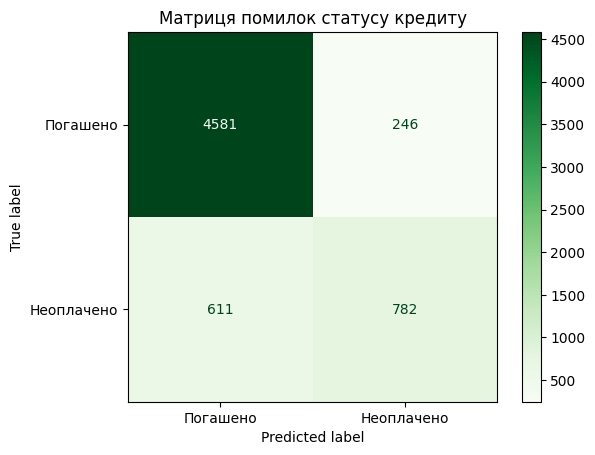

In [ ]:
# 5.1)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= ['Погашено', 'Неоплачено'])
disp.plot(cmap='Greens')
plt.title('Матриця помилок статусу кредиту')
plt.show()

In [ ]:
# 5.2)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Метрики якості моделі логіст. регресії\nAccuracy (Точність): {acc:.3f}\nPrecision (Влучність): {prec:.3f}\nRecall (Повнота): {rec:.3f}\nF1-score: {f1:.3f}')

Метрики якості моделі логіст. регресії
Accuracy (Точність): 0.862
Precision (Влучність): 0.761
Recall (Повнота): 0.561
F1-score: 0.646


In [ ]:
# 5.3)
from sklearn.metrics import roc_curve, roc_auc_score
import plotly.graph_objects as go

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_pred_proba[:, 1])

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC={auc:.3f})'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Випадковий класифікатор'))
fig.update_layout(title='ROC-крива', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate')
fig.show()

In [ ]:
# 5.4)
feats_importance = pd.DataFrame({
    'ознака' : x.columns,
    'коефіцієнт (ваги)' : model.coef_[0],
    '|коефіцієнт|' : np.abs(model.coef_[0])
}).sort_values('|коефіцієнт|', ascending=False)

display(feats_importance)

# Коефіцієнти (ваги) показують, як одна одиниця ознаки впливає на результативну змінну
#  (прогнозований кред. статус). Так, наприклад, наявність власного житла у позичальника зменшує на
# 0,476 передбачуваний кред. статус. Коефіцієнти з мінусом підвищують ймовірність погашення боргу,
#  і навпаки.

,ознака,коефіцієнт (ваги),|коефіцієнт|
4,loan_percent_income,1.324173,1.324173
2,loan_amnt,-0.559175,0.559175
12,loan_grade_D,0.556405,0.556405
3,loan_int_rate,0.529677,0.529677
5,person_home_ownership_OWN,-0.476438,0.476438
6,person_home_ownership_RENT,0.396279,0.396279
13,loan_grade_E,0.315269,0.315269
10,loan_intent_VENTURE,-0.308805,0.308805
15,loan_grade_G,0.238642,0.238642
7,loan_intent_EDUCATION,-0.207235,0.207235


5.5) Значення AUC 0,874 свідчить про досить хорошу якість моделі.

У тестовій вибірці 6220 позичальників, і ми хибно передбачили:
-неповернення кредиту серед добросовісних позичальників у 246 випадках;
-погашення кредиту серед дефолтних боржників у 611 випадках.
Вочевидь помилка 1 роду (False Positive) наразі має завеликий показник.

Серед ознак найвпливовішою є співвідношення кредиту до доходу позичальника (loan_percent_income). Далі йдуть розмір позики (loan_amnt), кред.рейтинг позичальника D (loan_grade_D), ставка % (loan_int_rate) та ін.



---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [ ]:
# 6.1)
thresholds = np.arange(0.05, 0.95, 0.05)
metrics_by_threshold = []

for threshold in thresholds:
  y_pred_custom = (y_pred_proba[:, 1] >= threshold).astype(int)

  metrics_by_threshold.append({
    'threshold' : threshold,
    'precisios' : precision_score(y_test, y_pred_custom),
    'recall' : recall_score(y_test, y_pred_custom),
    'f1' : f1_score(y_test, y_pred_custom)})

metrics_df = pd.DataFrame(metrics_by_threshold)

fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах рішення',
    labels={'value' : 'Значення метрики', 'threshold' : 'Поріг'})
fig.show()

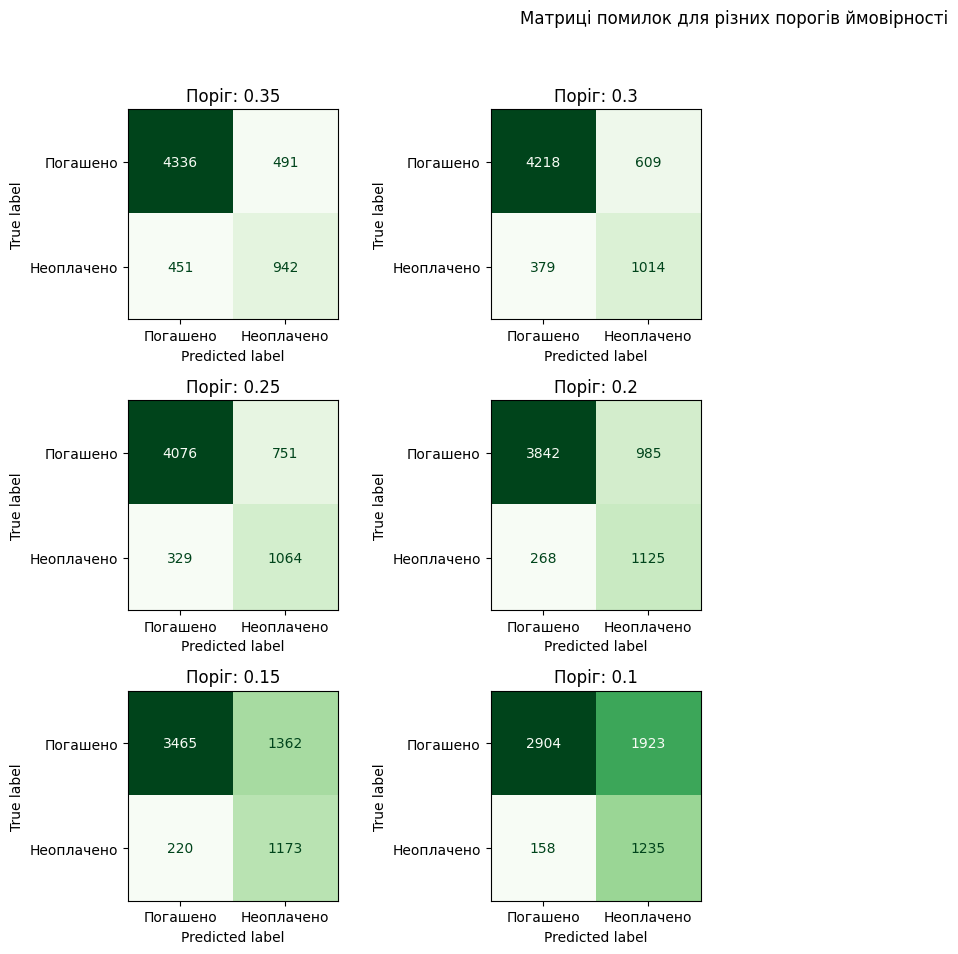

In [54]:
# 6.2) Отже, оптимальний поріг визначений в попередньому кроці - 0,35.
# Оскільки в нас було досить велике значення помилки 1 роду (False Positive),
#  порівняємо  матрицю помилок при порозі 0,35 та нижче, щоб подивитись на їхню варіацію.

cust_thresholds = [0.35, 0.3, 0.25, 0.2, 0.15, 0.1]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 10))
axes = axes.flatten()

for i, thresh in enumerate(cust_thresholds):
    y_pred_opt = y_pred_proba[:, 1] >= thresh

    cm = confusion_matrix(y_test, y_pred_opt)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Погашено', 'Неоплачено'])
    disp.plot(cmap='Greens', ax=axes[i], colorbar=False)

    axes[i].set_title(f'Поріг: {thresh}')

plt.suptitle('Матриці помилок для різних порогів ймовірності')
plt.tight_layout(rect=[0, 0.03, 0.6, 0.95])
plt.show()

# Рішення про прийнятний поріг ймовірності буде залежати від співвідношення вартості помилок,
#  але мені здається що в інтересах банку оптимально зменшувати показник False Positive (помилку 1 роду)
#  та підвищувати True Negative, звісно без надзвичайно перебільшеного значення False Negative
#  (помилки ІІ роду). Тому я вибрала би значення менше за 0,35 - принаймі 0,3.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.
